# ESTRUCTURA ÓPTIMA DE CAPITAL



In [8]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.costo_capital import rating_sintetico, reapalancar_beta, convertir_tasa

#modulo 1
ebit_base = 2456.3

# modulo 2
beta_desapalancado = 0.793
rf_usd = 0.0443
erp_total = 0.0682
spread_mexico = 0.0152
tasa_mx = 0.30
infl_mxn = 0.0375
infl_usd = 0.0225
wacc_actual = 0.1234

# balance a junio 2026
deuda_actual = 15935.7
acciones = 555980425
precio_mercado = 11.89

patrimonio_mercado = precio_mercado * acciones / 1e6
valor_firma = deuda_actual + patrimonio_mercado
ratio_actual = deuda_actual / valor_firma

print(f"Patrimonio de mercado : {patrimonio_mercado:,.1f}")
print(f"Valor de la firma     : {valor_firma:,.1f}")
print(f"Ratio de deuda actual : {ratio_actual:.1%}")

Patrimonio de mercado : 6,610.6
Valor de la firma     : 22,546.3
Ratio de deuda actual : 70.7%


In [9]:
def costo_capital_por_ratio(ratio_deuda, valor_firma, ebit, beta_u, rf, prima,
                            spread_pais, tasa_imp, infl_destino, infl_origen):
    """Calcula el costo de capital para un ratio de deuda dado. La cobertura se
    evalua con el gasto de intereses convertido a dolares, porque la tabla de
    ratings esta calibrada sobre empresas que se endeudan en esa moneda"""
    deuda = valor_firma * ratio_deuda
    patrimonio = valor_firma - deuda
    de = deuda / patrimonio

    beta_l = reapalancar_beta(beta_u, de, tasa_imp)
    ke = convertir_tasa(rf + beta_l * prima, infl_destino, infl_origen)

    kd_usd = rf + spread_pais + 0.05
    for _ in range(30):
        cobertura = ebit / (deuda * kd_usd)
        rating, spread = rating_sintetico(cobertura)
        nuevo = rf + spread_pais + spread
        if abs(nuevo - kd_usd) < 1e-7:
            break
        kd_usd = nuevo

    kd = convertir_tasa(kd_usd, infl_destino, infl_origen)
    kd_dt = kd * (1 - tasa_imp)

    return {
        "ratio_deuda": ratio_deuda,
        "de": de,
        "beta": beta_l,
        "ke": ke,
        "cobertura": cobertura,
        "rating": rating,
        "spread": spread,
        "kd_usd": kd_usd,
        "kd": kd,
        "kd_neto": kd_dt,
        "wacc": ke * (1 - ratio_deuda) + kd_dt * ratio_deuda,
    }

In [10]:
ratios = [r / 100 for r in range(5, 95, 5)]

cronograma = pd.DataFrame([
    costo_capital_por_ratio(r, valor_firma, ebit_base, beta_desapalancado,
                            rf_usd, erp_total, spread_mexico, tasa_mx,
                            infl_mxn, infl_usd)
    for r in ratios
])

cronograma[["ratio_deuda", "beta", "ke", "cobertura", "rating",
            "spread", "kd_neto", "wacc"]].round(4)

,ratio_deuda,beta,ke,cobertura,rating,spread,kd_neto,wacc
0,0.05,0.8222,0.1165,34.3133,Aaa/AAA,0.0040,0.0554,0.1135
1,0.10,0.8547,0.1188,17.1566,Aaa/AAA,0.0040,0.0554,0.1124
2,0.15,0.8910,0.1213,11.1738,Aa2/AA,0.0055,0.0564,0.1115
3,0.20,0.9318,0.1241,8.1913,A1/A+,0.0070,0.0575,0.1108
4,0.25,0.9780,0.1273,6.4752,A2/A,0.0078,0.0581,0.1100
5,0.30,1.0309,0.1310,5.3092,A3/A-,0.0089,0.0589,0.1093
6,0.35,1.0919,0.1352,4.4089,Baa2/BBB,0.0111,0.0604,0.1090
7,0.40,1.1631,0.1401,3.4963,Ba2/BB,0.0184,0.0656,0.1103
8,0.45,1.2472,0.1459,2.7828,B1/B+,0.0275,0.0721,0.1127
9,0.50,1.3481,0.1529,1.9736,B3/B-,0.0509,0.0887,0.1208


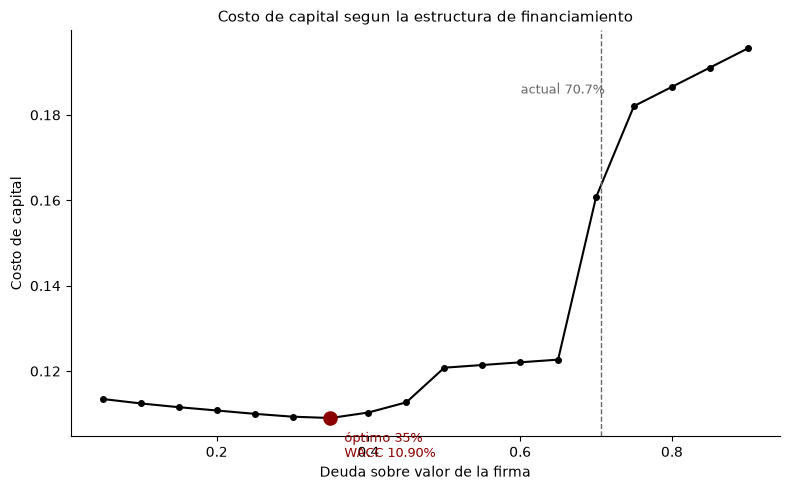

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(cronograma["ratio_deuda"], cronograma["wacc"],
        color="black", linewidth=1.5, marker="o", markersize=4)

optimo = cronograma.loc[cronograma["wacc"].idxmin()]
ax.scatter(optimo["ratio_deuda"], optimo["wacc"], s=90,
           color="darkred", zorder=5)
ax.annotate(f"óptimo {optimo['ratio_deuda']:.0%}\nWACC {optimo['wacc']:.2%}",
            (optimo["ratio_deuda"], optimo["wacc"]),
            textcoords="offset points", xytext=(10, -28), fontsize=9,
            color="darkred")

ax.axvline(ratio_actual, color="dimgray", linestyle="--", linewidth=1)
ax.annotate(f"actual {ratio_actual:.1%}", (ratio_actual, 0.185),
            textcoords="offset points", xytext=(-58, 0), fontsize=9,
            color="dimgray")

ax.set_xlabel("Deuda sobre valor de la firma")
ax.set_ylabel("Costo de capital")
ax.set_title("Costo de capital segun la estructura de financiamiento", fontsize=11)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/cronograma_wacc.png", dpi=150, bbox_inches="tight")
plt.show()

#### El óptimo está en 35%

| | Ratio de deuda | WACC | Rating |
|---|---|---|---|
| Óptimo | 35% | 10.90% | Baa2/BBB |
| Actual | 70.7% | 12.34% | B3/B− |

Traxión opera al doble de su estructura óptima. 

El acantilado aparece en el spread:

| Ratio | Cobertura | Rating | Spread |
|---|---|---|---|
| 35% | 4.41x | Baa2/BBB | 1.11% |
| 40% | 3.50x | Ba2/BB | 1.84% |
| 45% | 2.78x | B1/B+ | 2.75% |
| 50% | 1.97x | B3/B− | 5.09% |
| 70% | 0.84x | Ca2/CC | 12.61% |

El óptimo coincide con el último escalón de grado de inversión. Al pasar de 35% a 40% la empresa pierde esa calificación y el spread se duplica; entre 45% y 50% vuelve a duplicarse.

Por debajo del óptimo el WACC baja porque la deuda es más barata que elbpatrimonio y el escudo fiscal la abarata más. 

**Coherencia con el Módulo 2.** El cronograma calcula la cobertura con el gasto de intereses convertido a dólares, igual que en el cálculo del costo de deuda. En el escalón de 65% arroja B3/B- con cobertura de 1.52, muy cerca del B3/B- con cobertura de 1.64x que resultó del gasto de intereses bservado. Los dos módulos aplican el mismo criterio.